#### Case opti-4: Isobaric evaporation of ammonia in a large tank for long-term storage


In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import JAX library
import jax
import jax.numpy as jnp

# Import time
import time

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)


#### Setup tank and cryogen properties

In [2]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K


V_tank = 300 # Tank volume / m^3

a   = 1
d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 3.73e-3 # W/m2/K
U_V = 3.73e-3 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.9

# Specify tank operating pressure
P = 100000 # Pa

# Set fixed bottom heat ingress
q_b_fixed = 100/(np.pi*((8**2)/4))

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.90)

# # Initialise cryogen
cryogen = Cryogen(name = "hydrogen")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))
# comparison of heat flux
print("q_b used: ", q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))

The initial evaporation rate of hydrogen is 2.0 kg/h
q_b used:  1.9894367886486917  q_b free:  1.0362895158164553
Q_b used:  82.25726680148622  Q_b free:  42.84747506051564


Calculate initial evaporation rate and transient period

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of hydrogen is 2.0 kg/h
Transient period = 138873.933 s 
Simulation time: 39 h
BOR = 0.257 %


#### Simulation setup and execution

In [4]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 720

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
# large_tank.evaporate(evap_time)

In [5]:
opti = Opti_jax(large_tank)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


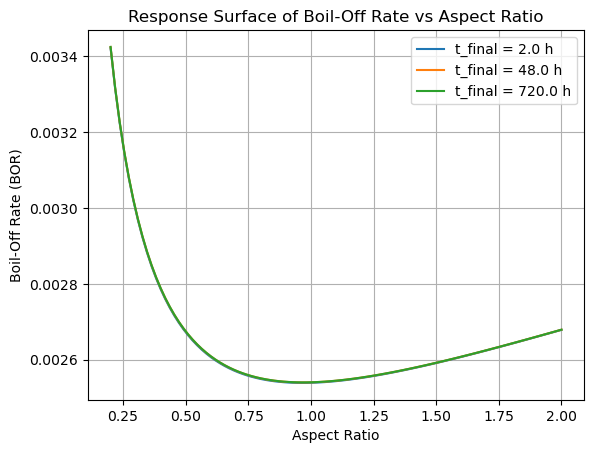

In [6]:
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 2*3600)
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 48*3600)
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 720*3600)

/home/milcaito/anaconda3/lib/python3.9/site-packages/cryoevap/optimize/opti_jax.py:788: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


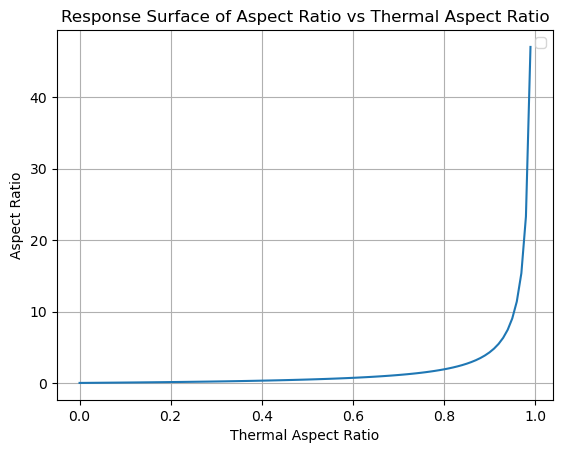

In [7]:
opti.plot_thermal_aspect_ratio(jnp.linspace(0, 0.99, 100),log=False)

/home/milcaito/anaconda3/lib/python3.9/site-packages/cryoevap/optimize/opti_jax.py:788: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


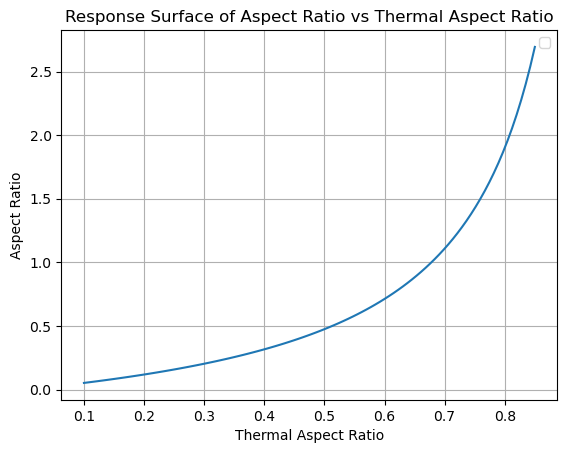

In [8]:
opti.plot_thermal_aspect_ratio(jnp.linspace(0.1, 0.85, 100),log=False)

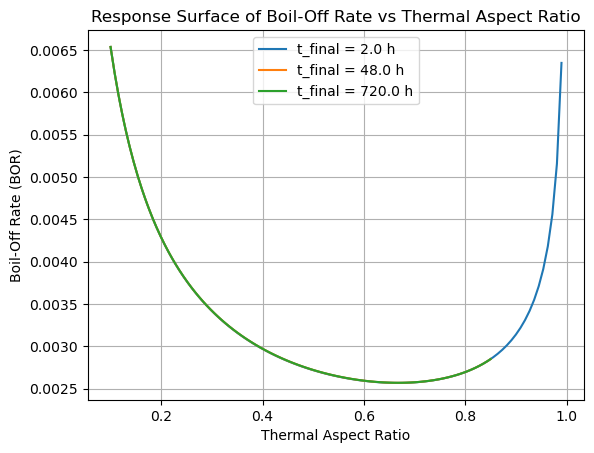

In [23]:
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.99, 100), 2*3600)
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.85, 100), 48*3600)
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.85, 100), 720*3600)

optimal Thermal Aspect Ratio: [0.66911002 0.66890982 0.66870962 0.66850942 0.66830922 0.66820912
 0.66810902 0.66800892 0.66790882 0.66740832]
optimal BOR: [0.04342269 0.01459106 0.00882373 0.00635132 0.00497723 0.00410239
 0.00349638 0.00305169 0.00271136 0.00244219]


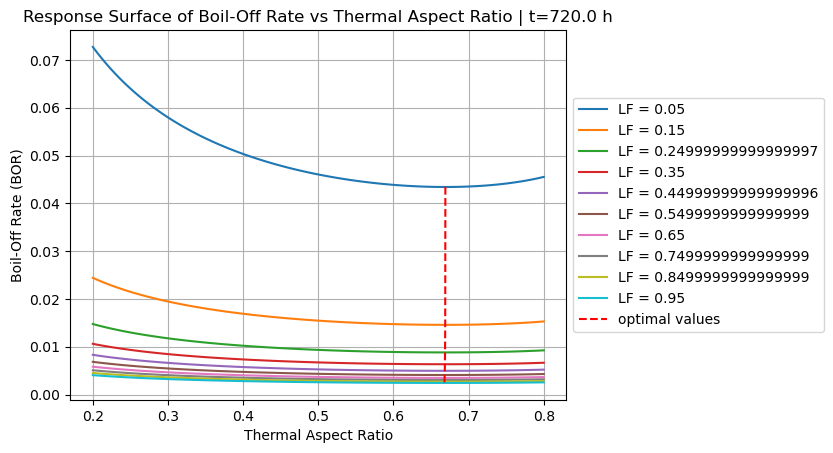

In [11]:
opti.plot_surface_response_thermal_liquid_filling(jnp.linspace(0.2, 0.8, 100), jnp.linspace(0.05, 0.95, 10),720*3600)

optimal Aspect Ratio: [1.07222222 1.05808081 1.04393939 1.03181818 1.01868687 1.00757576
 0.99646465 0.98535354 0.97424242 0.96313131]
optimal BOR: [0.04293322 0.01442646 0.00872412 0.00627957 0.00492096 0.00405598
 0.00345681 0.00301713 0.00268064 0.00241451]


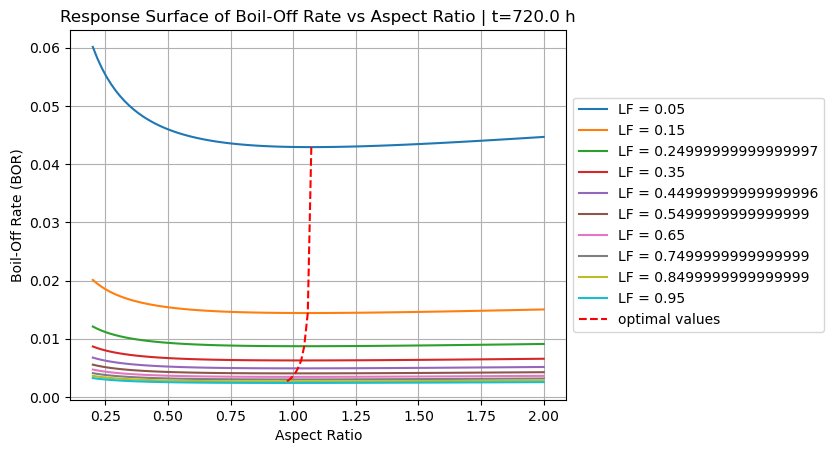

In [12]:
opti.plot_surface_response_liquid_filling(jnp.linspace(0.2, 2, 100), jnp.linspace(0.05, 0.95, 10),720*3600)

In [18]:
start_time = time.time()
opti.thermal_optimize_grid_with_refinement(verbose=True, t_final=2*3600, coarse_samples=100, fine_samples=100,
                                   thermal_aspect_ratio_min=0.1, thermal_aspect_ratio_max=0.8, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.665657, BOR: 2.568018e-03
Phase 2: Fine grid search with 100 samples...
Refined optimal thermal aspect ratio: 0.667172
Minimum BOR: 2.568005e-03
Tiempo de ejecución: 0.04 segundos


In [17]:
start_time = time.time()
opti.thermal_optimize_grid_with_refinement(verbose=True, t_final=48*3600, coarse_samples=100, fine_samples=100,
                                   thermal_aspect_ratio_min=0.1, thermal_aspect_ratio_max=0.8, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.665657, BOR: 2.569368e-03
Phase 2: Fine grid search with 100 samples...
Refined optimal thermal aspect ratio: 0.668182
Minimum BOR: 2.569344e-03
Tiempo de ejecución: 0.35 segundos


In [19]:
start_time = time.time()
opti.thermal_optimize_grid_with_refinement(verbose=True, t_final=720*3600, coarse_samples=100, fine_samples=100,
                                   thermal_aspect_ratio_min=0.1, thermal_aspect_ratio_max=0.8, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.665657, BOR: 2.569467e-03
Phase 2: Fine grid search with 100 samples...
Refined optimal thermal aspect ratio: 0.668182
Minimum BOR: 2.569441e-03
Tiempo de ejecución: 5.28 segundos


In [9]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=2*3600, coarse_samples=100, fine_samples=1000,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.963636, BOR: 2.538910e-03
Phase 2: Fine grid search with 1000 samples...
Refined optimal aspect ratio: 0.966289
Minimum BOR: 2.538908e-03
Tiempo de ejecución: 4.34 segundos


In [9]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=48*3600, coarse_samples=100, fine_samples=1000,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.963636, BOR: 2.540233e-03
Phase 2: Fine grid search with 1000 samples...
Refined optimal aspect ratio: 0.969092
Minimum BOR: 2.540224e-03
Tiempo de ejecución: 2.27 segundos


In [10]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=720*3600, coarse_samples=100, fine_samples=100,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.963636, BOR: 2.540330e-03
Phase 2: Fine grid search with 100 samples...
Refined optimal aspect ratio: 0.969192
Minimum BOR: 2.540321e-03
Tiempo de ejecución: 1.10 segundos


In [11]:
# optimal_aspect_ratio = opti.optimize(max_iter = 500, t_final = 2 * 3600, lr = 1e-2, x0 = 0, lr_2 = 1e-3, iter_decay_lr=75)
# opti.plot_loss_history()

In [12]:
opti.optimal_aspect_ratio

Array(0.96919192, dtype=float64)

#### Visualisation of results

#### Vapour temperature

In [13]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

TypeError: The solution object tank.sol does not exist.
Run tank.evaporate(t) to generate a solution
and thereafter run tank.plot_tv() again

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

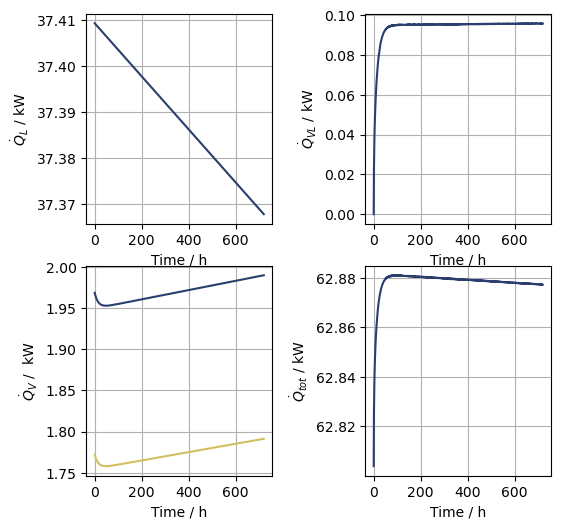

In [ ]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

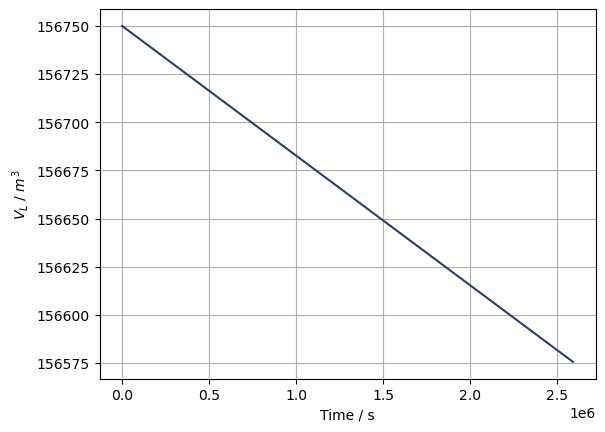

In [ ]:
large_tank.plot_V_L()

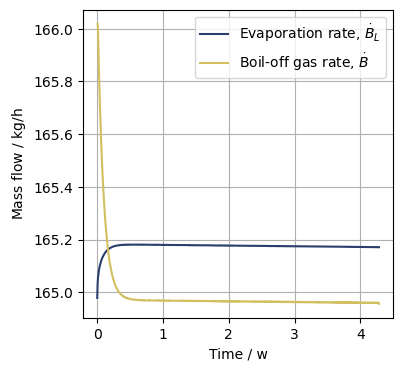

In [ ]:
large_tank.plot_BOG(unit='kg/h', t_unit='w')

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [ ]:
# Import pandas 
import pandas as pd

In [ ]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(large_tank.data)

# Save file to the current working directory
df_evap.to_csv('methane_165000m3.csv')

# Show the first five columns of the dataframe in console
df_evap.head()

In [ ]:
# BOR = (1 - large_tank.data['V_L'][-1]/large_tank.data['V_L'][0])* (86400/large_tank.data['Time'][-1])
BOR = large_tank.BOR()
print("BOR = %.3e %%" % (100 * BOR))

In [ ]:
large_tank.BOR()

In [ ]:
large_tank.data['Time'][-1]

In [ ]:
large_tank.plot_tv_BOG(t_unit='w')

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.